# Import the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load Dataset

In [12]:
df = pd.read_csv(r'data/mplads_data.csv')

# Exploratory data analysis

In [13]:
df.head()

,project_id,work_name,category,mp_name,state,district,agency_name,sanction_date,expected_completion,actual_completion,...,expenditure,progress_percentage,latitude,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2023-10-07,2024-04-26,NaN,...,1739533.45,62.05,12.523841,69.684425,In Progress,False,False,False,False,True
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,2023-10-07,2024-07-20,NaN,...,4080008.07,47.58,32.140837,74.157834,In Progress,True,False,False,False,False
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,2023-02-17,2023-11-21,2024-04-17,...,802943.03,47.35,16.445645,85.743734,Delayed,False,False,False,True,False
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,2023-07-05,2024-05-27,NaN,...,1345244.10,50.93,13.790540,82.912799,In Progress,True,False,False,False,False
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,2023-11-22,2024-08-21,NaN,...,1491206.67,42.32,35.517681,96.003329,In Progress,False,False,False,False,False


In [14]:
df.shape

(5000, 23)

In [15]:
df.sample(5)

,project_id,work_name,category,mp_name,state,district,agency_name,sanction_date,expected_completion,actual_completion,...,expenditure,progress_percentage,latitude,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate
4964,MPLAD-2024-04964,Construction of Roads in District_15,Roads,MP_6,Tamil Nadu,District_15,Agency_27,2023-07-18,2024-04-11,NaN,...,2803675.42,55.53,30.657356,82.862712,In Progress,False,False,False,False,False
3029,MPLAD-2024-03029,Construction of Education in District_6,Roads,MP_43,Maharashtra,District_17,Agency_10,2023-03-20,2023-11-21,NaN,...,1440403.56,46.40,25.226468,93.030985,In Progress,False,False,False,False,True
1608,MPLAD-2024-01608,Construction of Community Hall in District_4,Community Hall,MP_35,Tamil Nadu,District_4,Agency_26,2023-11-11,2024-10-02,NaN,...,1219781.05,56.43,16.776046,85.757088,In Progress,True,False,False,False,False
3486,MPLAD-2024-03486,Construction of Roads in District_1,Roads,MP_15,Uttar Pradesh,District_1,Agency_21,2023-02-04,2023-09-12,2024-02-28,...,1718134.52,91.73,36.311832,79.894002,Delayed,False,False,False,True,False
1407,MPLAD-2024-01407,Construction of Roads in District_14,Roads,MP_30,Karnataka,District_14,Agency_29,2023-10-30,2024-06-23,NaN,...,1584505.47,52.56,33.027835,81.960099,In Progress,False,False,False,False,False


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   project_id           5000 non-null   str    
 1   work_name            5000 non-null   str    
 2   category             5000 non-null   str    
 3   mp_name              5000 non-null   str    
 4   state                5000 non-null   str    
 5   district             5000 non-null   str    
 6   agency_name          5000 non-null   str    
 7   sanction_date        5000 non-null   str    
 8   expected_completion  5000 non-null   str    
 9   actual_completion    730 non-null    str    
 10  estimated_cost       5000 non-null   float64
 11  sanctioned_amount    5000 non-null   float64
 12  released_amount      5000 non-null   float64
 13  expenditure          5000 non-null   float64
 14  progress_percentage  5000 non-null   float64
 15  latitude             5000 non-null   float64
 16 

In [17]:
df.describe()

,estimated_cost,sanctioned_amount,released_amount,expenditure,progress_percentage,latitude,longitude
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,2.995754e+06,3.311700e+06,2.491829e+06,1.942739e+06,53.552118,22.347427,82.489385
std,1.149900e+06,1.633731e+06,1.336243e+06,1.231036e+06,21.745249,8.285657,8.359277
min,1.000022e+06,9.750635e+05,5.075945e+05,2.959609e+05,3.430000,8.007045,68.002830
25%,1.977612e+06,2.104002e+06,1.518150e+06,1.105622e+06,40.522500,15.167965,75.314508
50%,3.002959e+06,3.139897e+06,2.284204e+06,1.674581e+06,52.305000,22.372619,82.379523
75%,3.994806e+06,4.197690e+06,3.157227e+06,2.455185e+06,67.527500,29.469190,89.709054
max,4.998625e+06,1.185101e+07,1.151974e+07,1.459243e+07,100.000000,36.996272,96.991813


# Data Cleaning

In [18]:
# find the missing values 

In [19]:
df.isnull().sum()

project_id                0
work_name                 0
category                  0
mp_name                   0
state                     0
district                  0
agency_name               0
sanction_date             0
expected_completion       0
actual_completion      4270
estimated_cost            0
sanctioned_amount         0
released_amount           0
expenditure               0
progress_percentage       0
latitude                  0
longitude                 0
status                    0
is_cost_anomaly           0
is_exp_anomaly            0
is_progress_anomaly       0
is_delay                  0
is_duplicate              0
dtype: int64

In [20]:
# missing values -> actual_completion(4270)

In [21]:
df = df.drop(columns=['actual_completion'])

In [22]:
df.isnull().sum()

project_id             0
work_name              0
category               0
mp_name                0
state                  0
district               0
agency_name            0
sanction_date          0
expected_completion    0
estimated_cost         0
sanctioned_amount      0
released_amount        0
expenditure            0
progress_percentage    0
latitude               0
longitude              0
status                 0
is_cost_anomaly        0
is_exp_anomaly         0
is_progress_anomaly    0
is_delay               0
is_duplicate           0
dtype: int64

In [23]:
# find the duplicates

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
# there is no duplicates 

In [26]:
df.dtypes

project_id                 str
work_name                  str
category                   str
mp_name                    str
state                      str
district                   str
agency_name                str
sanction_date              str
expected_completion        str
estimated_cost         float64
sanctioned_amount      float64
released_amount        float64
expenditure            float64
progress_percentage    float64
latitude               float64
longitude              float64
status                     str
is_cost_anomaly           bool
is_exp_anomaly            bool
is_progress_anomaly       bool
is_delay                  bool
is_duplicate              bool
dtype: object

In [27]:
df.head()

,project_id,work_name,category,mp_name,state,district,agency_name,sanction_date,expected_completion,estimated_cost,...,expenditure,progress_percentage,latitude,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2023-10-07,2024-04-26,2498160.48,...,1739533.45,62.05,12.523841,69.684425,In Progress,False,False,False,False,True
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,2023-10-07,2024-07-20,4464704.58,...,4080008.07,47.58,32.140837,74.157834,In Progress,True,False,False,False,False
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,2023-02-17,2023-11-21,1727299.87,...,802943.03,47.35,16.445645,85.743734,Delayed,False,False,False,True,False
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,2023-07-05,2024-05-27,1557975.44,...,1345244.10,50.93,13.790540,82.912799,In Progress,True,False,False,False,False
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,2023-11-22,2024-08-21,3369658.28,...,1491206.67,42.32,35.517681,96.003329,In Progress,False,False,False,False,False


In [28]:
# date conversion
df["sanction_date"] = pd.to_datetime(df["sanction_date"],errors = 'coerce')
df["expected_completion"] = pd.to_datetime(df["expected_completion"],errors = 'coerce')

In [29]:
df["sanction_date"].dtypes

dtype('<M8[us]')

In [30]:
df["expected_completion"].dtypes

dtype('<M8[us]')

In [31]:
df["sanction_year"] = df["sanction_date"].dt.year

In [32]:
df["sanction_month"] = df["sanction_date"].dt.month

In [33]:
df["expected_duration_date"] = (
    df["expected_completion"] - df["sanction_date"]
).dt.days

In [34]:
df.head(10)

,project_id,work_name,category,mp_name,state,district,agency_name,sanction_date,expected_completion,estimated_cost,...,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate,sanction_year,sanction_month,expected_duration_date
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2023-10-07,2024-04-26,2498160.48,...,69.684425,In Progress,False,False,False,False,True,2023,10,202
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,2023-10-07,2024-07-20,4464704.58,...,74.157834,In Progress,True,False,False,False,False,2023,10,287
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,2023-02-17,2023-11-21,1727299.87,...,85.743734,Delayed,False,False,False,True,False,2023,2,277
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,2023-07-05,2024-05-27,1557975.44,...,82.912799,In Progress,True,False,False,False,False,2023,7,327
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,2023-11-22,2024-08-21,3369658.28,...,96.003329,In Progress,False,False,False,False,False,2023,11,273
5,MPLAD-2024-00005,Construction of Community Hall in District_3,Community Hall,MP_39,Tamil Nadu,District_3,Agency_21,2023-07-14,2024-03-19,4233589.39,...,82.360130,In Progress,False,False,False,False,False,2023,7,249
6,MPLAD-2024-00006,Construction of Sanitation in District_11,Sanitation,MP_4,Uttar Pradesh,District_11,Agency_8,2023-02-03,2023-09-25,1137554.08,...,83.854598,In Progress,False,False,False,False,False,2023,2,234
7,MPLAD-2024-00007,Construction of Community Hall in District_7,Community Hall,MP_42,Tamil Nadu,District_7,Agency_16,2023-05-16,2023-12-17,1739417.82,...,94.734353,In Progress,False,False,False,False,False,2023,5,215
8,MPLAD-2024-00008,Construction of Health in District_14,Health,MP_38,Gujarat,District_14,Agency_13,2023-09-10,2024-03-31,1353970.01,...,92.033388,In Progress,False,False,False,False,False,2023,9,203
9,MPLAD-2024-00009,Construction of Health in District_14,Education,MP_39,Uttar Pradesh,District_14,Agency_3,2023-05-09,2024-03-25,2427013.31,...,92.033488,In Progress,False,False,False,False,True,2023,5,321


In [35]:
df = df.drop(columns = ["sanction_date","expected_completion"])

In [36]:
df.head(5)

,project_id,work_name,category,mp_name,state,district,agency_name,estimated_cost,sanctioned_amount,released_amount,...,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate,sanction_year,sanction_month,expected_duration_date
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2498160.48,2610756.14,2260906.91,...,69.684425,In Progress,False,False,False,False,True,2023,10,202
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,4464704.58,9380857.82,8011593.00,...,74.157834,In Progress,True,False,False,False,False,2023,10,287
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,1727299.87,1672614.33,1090747.14,...,85.743734,Delayed,False,False,False,True,False,2023,2,277
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,1557975.44,2792117.35,1907521.31,...,82.912799,In Progress,True,False,False,False,False,2023,7,327
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,3369658.28,3216827.56,2585597.29,...,96.003329,In Progress,False,False,False,False,False,2023,11,273


In [37]:
# univariate EDA

In [38]:
# 1. Status 
df['status'].value_counts()

status
In Progress    4270
Delayed         506
Completed       224
Name: count, dtype: int64

<Axes: xlabel='status', ylabel='count'>

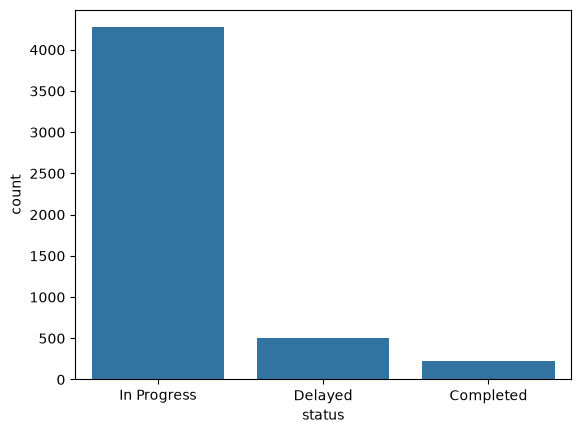

In [39]:
sns.countplot(x=df['status'])

In [40]:
df['category'].value_counts()

category
Water Supply      861
Sanitation        859
Roads             832
Community Hall    825
Education         818
Health            805
Name: count, dtype: int64

<Axes: xlabel='category', ylabel='count'>

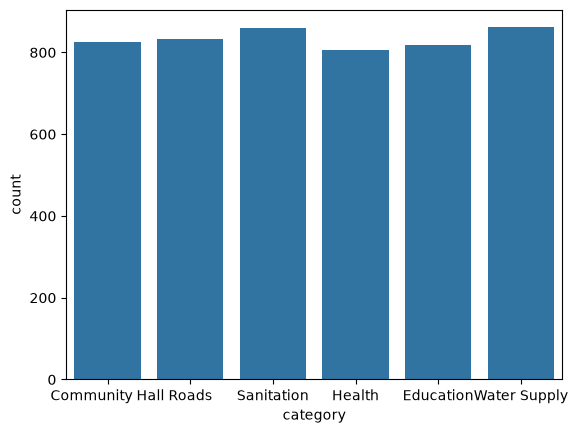

In [41]:
sns.countplot(x=df['category'])

In [42]:
df['state'].value_counts()

state
Karnataka        1083
Maharashtra       983
Uttar Pradesh     981
Gujarat           981
Tamil Nadu        972
Name: count, dtype: int64

<Axes: xlabel='state', ylabel='count'>

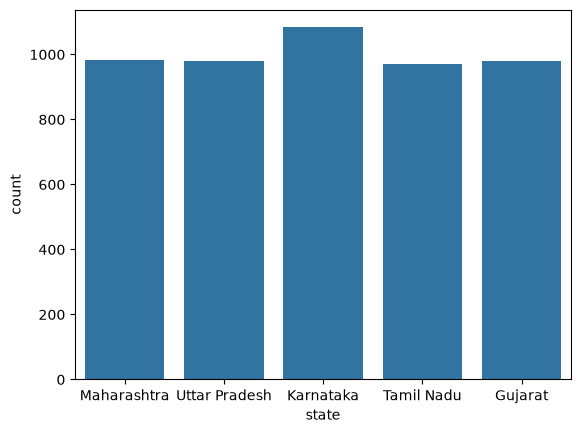

In [43]:
sns.countplot(x=df['state'])

In [44]:
df['district'].value_counts()

district
District_10    297
District_1     286
District_13    284
District_8     278
District_7     274
District_3     273
District_14    271
District_17    268
District_19    268
District_4     266
District_6     263
District_18    255
District_16    254
District_5     252
District_11    251
District_2     248
District_12    238
District_15    238
District_9     236
Name: count, dtype: int64

<Axes: xlabel='district', ylabel='count'>

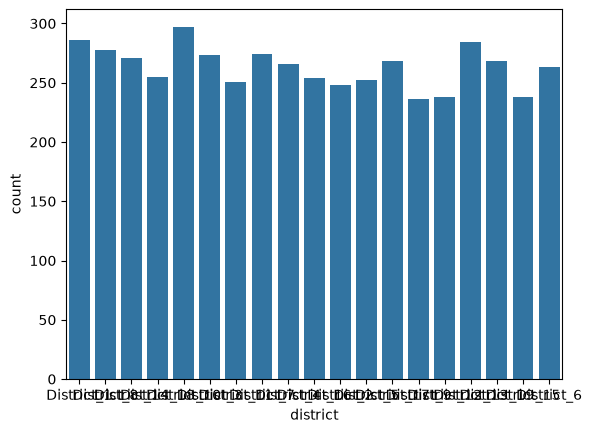

In [45]:
sns.countplot(x=df['district'],)

In [46]:
df['mp_name'].value_counts()

mp_name
MP_22    129
MP_7     122
MP_42    120
MP_29    120
MP_41    117
MP_43    117
MP_10    117
MP_14    115
MP_49    114
MP_21    110
MP_4     108
MP_1     108
MP_3     107
MP_28    106
MP_44    106
MP_17    106
MP_33    105
MP_26    105
MP_8     103
MP_20    103
MP_34    103
MP_37    103
MP_27    102
MP_9     101
MP_48    100
MP_36    100
MP_31    100
MP_23    100
MP_6      99
MP_38     99
MP_18     99
MP_16     99
MP_45     97
MP_25     97
MP_39     96
MP_5      96
MP_35     95
MP_2      94
MP_11     93
MP_24     93
MP_13     92
MP_12     92
MP_40     91
MP_19     90
MP_30     90
MP_15     87
MP_32     85
MP_47     85
MP_46     84
Name: count, dtype: int64

In [47]:
df['agency_name'].value_counts()

agency_name
Agency_22    212
Agency_5     198
Agency_14    190
Agency_24    189
Agency_25    186
Agency_23    183
Agency_8     181
Agency_6     181
Agency_13    179
Agency_19    177
Agency_26    176
Agency_21    175
Agency_11    175
Agency_20    174
Agency_7     174
Agency_4     173
Agency_1     171
Agency_2     171
Agency_16    168
Agency_17    166
Agency_15    166
Agency_3     163
Agency_28    161
Agency_12    160
Agency_9     157
Agency_29    154
Agency_10    151
Agency_27    148
Agency_18    141
Name: count, dtype: int64

In [48]:
df.head()

,project_id,work_name,category,mp_name,state,district,agency_name,estimated_cost,sanctioned_amount,released_amount,...,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate,sanction_year,sanction_month,expected_duration_date
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2498160.48,2610756.14,2260906.91,...,69.684425,In Progress,False,False,False,False,True,2023,10,202
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,4464704.58,9380857.82,8011593.00,...,74.157834,In Progress,True,False,False,False,False,2023,10,287
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,1727299.87,1672614.33,1090747.14,...,85.743734,Delayed,False,False,False,True,False,2023,2,277
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,1557975.44,2792117.35,1907521.31,...,82.912799,In Progress,True,False,False,False,False,2023,7,327
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,3369658.28,3216827.56,2585597.29,...,96.003329,In Progress,False,False,False,False,False,2023,11,273


In [49]:
target_cols = [
    "is_cost_anomaly",
    "is_exp_anomaly",
    "is_progress_anomaly",
    "is_delay",
    "is_duplicate"
]

df[target_cols].sum()

is_cost_anomaly        534
is_exp_anomaly         492
is_progress_anomaly    505
is_delay               506
is_duplicate           223
dtype: int64

In [50]:
df[target_cols] = df[target_cols].astype(int)

In [51]:
df.head()

,project_id,work_name,category,mp_name,state,district,agency_name,estimated_cost,sanctioned_amount,released_amount,...,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate,sanction_year,sanction_month,expected_duration_date
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2498160.48,2610756.14,2260906.91,...,69.684425,In Progress,0,0,0,0,1,2023,10,202
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,4464704.58,9380857.82,8011593.00,...,74.157834,In Progress,1,0,0,0,0,2023,10,287
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,1727299.87,1672614.33,1090747.14,...,85.743734,Delayed,0,0,0,1,0,2023,2,277
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,1557975.44,2792117.35,1907521.31,...,82.912799,In Progress,1,0,0,0,0,2023,7,327
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,3369658.28,3216827.56,2585597.29,...,96.003329,In Progress,0,0,0,0,0,2023,11,273


In [52]:
from sklearn.preprocessing import OrdinalEncoder

In [53]:
oe = OrdinalEncoder()

In [54]:
df['status'] = oe.fit_transform(
    df[['status']]
)

In [55]:
df.head()

,project_id,work_name,category,mp_name,state,district,agency_name,estimated_cost,sanctioned_amount,released_amount,...,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate,sanction_year,sanction_month,expected_duration_date
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2498160.48,2610756.14,2260906.91,...,69.684425,2.0,0,0,0,0,1,2023,10,202
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,4464704.58,9380857.82,8011593.00,...,74.157834,2.0,1,0,0,0,0,2023,10,287
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,1727299.87,1672614.33,1090747.14,...,85.743734,1.0,0,0,0,1,0,2023,2,277
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,1557975.44,2792117.35,1907521.31,...,82.912799,2.0,1,0,0,0,0,2023,7,327
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,3369658.28,3216827.56,2585597.29,...,96.003329,2.0,0,0,0,0,0,2023,11,273


In [56]:
df = pd.get_dummies(df,columns=['agency_name'],dtype = int)

In [57]:
df = pd.get_dummies(df,columns=['district'],dtype = int)

In [58]:
df = pd.get_dummies(df,columns=['state'],dtype = int)

In [59]:
df = pd.get_dummies(df,columns=['mp_name'],dtype = int)

In [60]:
df = pd.get_dummies(df,columns=['category'],dtype=int)

In [61]:
df.head()

,project_id,work_name,estimated_cost,sanctioned_amount,released_amount,expenditure,progress_percentage,latitude,longitude,status,...,mp_name_MP_6,mp_name_MP_7,mp_name_MP_8,mp_name_MP_9,category_Community Hall,category_Education,category_Health,category_Roads,category_Sanitation,category_Water Supply
0,MPLAD-2024-00000,Construction of Community Hall in District_1,2498160.48,2610756.14,2260906.91,1739533.45,62.05,12.523841,69.684425,2.0,...,0,0,0,0,1,0,0,0,0,0
1,MPLAD-2024-00001,Construction of Roads in District_8,4464704.58,9380857.82,8011593.00,4080008.07,47.58,32.140837,74.157834,2.0,...,0,0,0,0,0,0,0,1,0,0
2,MPLAD-2024-00002,Construction of Roads in District_14,1727299.87,1672614.33,1090747.14,802943.03,47.35,16.445645,85.743734,1.0,...,0,0,0,0,0,0,0,1,0,0
3,MPLAD-2024-00003,Construction of Roads in District_18,1557975.44,2792117.35,1907521.31,1345244.10,50.93,13.790540,82.912799,2.0,...,0,0,1,0,0,0,0,1,0,0
4,MPLAD-2024-00004,Construction of Community Hall in District_10,3369658.28,3216827.56,2585597.29,1491206.67,42.32,35.517681,96.003329,2.0,...,1,0,0,0,1,0,0,0,0,0


In [62]:
df.drop(columns=[
    'project_id',
    'work_name',
], inplace=True)

In [63]:
df.head()

,estimated_cost,sanctioned_amount,released_amount,expenditure,progress_percentage,latitude,longitude,status,is_cost_anomaly,is_exp_anomaly,...,mp_name_MP_6,mp_name_MP_7,mp_name_MP_8,mp_name_MP_9,category_Community Hall,category_Education,category_Health,category_Roads,category_Sanitation,category_Water Supply
0,2498160.48,2610756.14,2260906.91,1739533.45,62.05,12.523841,69.684425,2.0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,4464704.58,9380857.82,8011593.00,4080008.07,47.58,32.140837,74.157834,2.0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,1727299.87,1672614.33,1090747.14,802943.03,47.35,16.445645,85.743734,1.0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1557975.44,2792117.35,1907521.31,1345244.10,50.93,13.790540,82.912799,2.0,1,0,...,0,0,1,0,0,0,0,1,0,0
4,3369658.28,3216827.56,2585597.29,1491206.67,42.32,35.517681,96.003329,2.0,0,0,...,1,0,0,0,1,0,0,0,0,0


In [64]:
for col in df.columns:
    print(col)

estimated_cost
sanctioned_amount
released_amount
expenditure
progress_percentage
latitude
longitude
status
is_cost_anomaly
is_exp_anomaly
is_progress_anomaly
is_delay
is_duplicate
sanction_year
sanction_month
expected_duration_date
agency_name_Agency_1
agency_name_Agency_10
agency_name_Agency_11
agency_name_Agency_12
agency_name_Agency_13
agency_name_Agency_14
agency_name_Agency_15
agency_name_Agency_16
agency_name_Agency_17
agency_name_Agency_18
agency_name_Agency_19
agency_name_Agency_2
agency_name_Agency_20
agency_name_Agency_21
agency_name_Agency_22
agency_name_Agency_23
agency_name_Agency_24
agency_name_Agency_25
agency_name_Agency_26
agency_name_Agency_27
agency_name_Agency_28
agency_name_Agency_29
agency_name_Agency_3
agency_name_Agency_4
agency_name_Agency_5
agency_name_Agency_6
agency_name_Agency_7
agency_name_Agency_8
agency_name_Agency_9
district_District_1
district_District_10
district_District_11
district_District_12
district_District_13
district_District_14
district_Distr

# Train Test Split

# Target -> 1. 'is_cost_anomaly'

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
target = 'is_cost_anomaly'

In [67]:
X = df.drop(columns=[target])
y = df[target]

In [68]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.33,random_state = 42,
    stratify=y
)

In [69]:
y_train.shape

(3350,)

In [70]:
X_train.shape

(3350, 123)

In [71]:
y_test.shape

(1650,)

In [72]:
X_test.shape

(1650, 123)

# Feature Scailing

In [73]:
from sklearn.preprocessing import StandardScaler

In [74]:
scaler = StandardScaler()

In [75]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
X_train_scaled

array([[-0.49365252, -0.55411082, -0.20713029, ..., -0.4436846 ,
        -0.46757348, -0.46139919],
       [-0.58158817, -0.59519983, -0.23711919, ...,  2.25385332,
        -0.46757348, -0.46139919],
       [-0.025097  ,  2.48805253,  3.58664992, ..., -0.4436846 ,
         2.1387013 , -0.46139919],
       ...,
       [ 0.88247535,  0.4007197 ,  0.65116284, ..., -0.4436846 ,
        -0.46757348,  2.16732068],
       [-0.34217039, -0.42120951, -0.35711759, ..., -0.4436846 ,
        -0.46757348,  2.16732068],
       [-1.5607027 , -1.26458353, -1.34341741, ..., -0.4436846 ,
         2.1387013 , -0.46139919]], shape=(3350, 123))

In [77]:
X_test_scaled

array([[ 1.53629248,  0.84572217,  1.45313111, ..., -0.4436846 ,
        -0.46757348, -0.46139919],
       [-1.49331426, -1.25271435, -1.0958379 , ...,  2.25385332,
        -0.46757348, -0.46139919],
       [ 1.36559333,  0.73864512,  0.02710959, ..., -0.4436846 ,
        -0.46757348, -0.46139919],
       ...,
       [-1.20121043, -1.02860595, -1.10482307, ...,  2.25385332,
        -0.46757348, -0.46139919],
       [ 0.15563704, -0.00368811,  0.16647926, ..., -0.4436846 ,
        -0.46757348, -0.46139919],
       [-0.14740388, -0.2326565 , -0.66437332, ..., -0.4436846 ,
        -0.46757348, -0.46139919]], shape=(1650, 123))

# Logostic Regression 

In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
lr = LogisticRegression(max_iter=1000)

In [80]:
lr.fit(X_train_scaled,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [81]:
y_pred_lr = lr.predict(X_test_scaled)

In [82]:
y_pred_lr

array([0, 0, 0, ..., 0, 0, 0], shape=(1650,))

In [83]:
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]

In [84]:
y_proba_lr

array([4.97896815e-03, 1.67209687e-03, 2.25214240e-05, ...,
       2.88273035e-03, 5.25404291e-03, 2.48209609e-03], shape=(1650,))

In [85]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score,classification_report,confusion_matrix

In [86]:
accuracy_score(y_test,y_pred_lr)

0.9963636363636363

In [87]:
precision_score(y_test,y_pred_lr)

1.0

In [88]:
recall_score(y_test,y_pred_lr)

0.9659090909090909

In [89]:
roc_auc_score(y_test,y_proba_lr)

0.9999961453065251

In [90]:
cr = classification_report(y_test,y_pred_lr)

In [91]:
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1474
           1       1.00      0.97      0.98       176

    accuracy                           1.00      1650
   macro avg       1.00      0.98      0.99      1650
weighted avg       1.00      1.00      1.00      1650



In [92]:
confusion_matrix(y_test,y_pred_lr)

array([[1474,    0],
       [   6,  170]])

# Decision Tree 

In [93]:
from sklearn.tree import DecisionTreeClassifier

In [94]:
dt = DecisionTreeClassifier()

In [95]:
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [96]:
y_pred_dt = dt.predict(X_test)

In [97]:
y_proba_dt = dt.predict_proba(X_test)[:,1]

In [98]:
accuracy_score(y_test,y_pred_dt)

0.9987878787878788

In [99]:
precision_score(y_test,y_pred_dt)

0.9887640449438202

In [100]:
recall_score(y_test,y_pred_dt)

1.0

In [101]:
roc_auc_score(y_test,y_proba_dt)

0.9993215739484397

In [102]:
cr_dt = classification_report(y_test,y_pred_dt)

In [103]:
print(cr_dt)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1474
           1       0.99      1.00      0.99       176

    accuracy                           1.00      1650
   macro avg       0.99      1.00      1.00      1650
weighted avg       1.00      1.00      1.00      1650



In [104]:
confusion_matrix(y_test,y_pred_dt)

array([[1472,    2],
       [   0,  176]])

# Random Forest

In [105]:
from sklearn.ensemble import RandomForestClassifier

In [106]:
rdt = RandomForestClassifier()

In [107]:
rdt.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [108]:
y_pred_rdt = rdt.predict(X_test)

In [109]:
y_proba_rdt = rdt.predict_proba(X_test)[:,1]

In [110]:
accuracy_score(y_test,y_pred_rdt)

0.9593939393939394

In [111]:
precision_score(y_test,y_pred_rdt)

0.9823008849557522

In [112]:
recall_score(y_test,y_pred_rdt)

0.6306818181818182

In [113]:
roc_auc_score(y_test,y_proba_rdt)

0.9966155791291476

In [114]:
cr_rdt= classification_report(y_test,y_pred_rdt)

In [115]:
print(cr_rdt)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1474
           1       0.98      0.63      0.77       176

    accuracy                           0.96      1650
   macro avg       0.97      0.81      0.87      1650
weighted avg       0.96      0.96      0.96      1650



In [116]:
confusion_matrix(y_test,y_pred_rdt)

array([[1472,    2],
       [  65,  111]])

# Gradient Boosting

In [117]:
from sklearn.ensemble import GradientBoostingClassifier

In [118]:
gb = GradientBoostingClassifier()

In [119]:
gb.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [120]:
y_pred_gb = gb.predict(X_test)

In [121]:
y_proba_gb = gb.predict_proba(X_test)[:,1]

In [122]:
accuracy_score(y_test,y_pred_gb)

0.9993939393939394

In [123]:
precision_score(y_test,y_pred_gb)

0.9943502824858758

In [124]:
recall_score(y_test,y_pred_gb)

1.0

In [125]:
roc_auc_score(y_test,y_proba_gb)

0.9998997779696559

In [126]:
cr_gb = classification_report(y_test,y_pred_gb)

In [127]:
print(cr_gb)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1474
           1       0.99      1.00      1.00       176

    accuracy                           1.00      1650
   macro avg       1.00      1.00      1.00      1650
weighted avg       1.00      1.00      1.00      1650



In [128]:
confusion_matrix(y_test,y_pred_gb)

array([[1473,    1],
       [   0,  176]])

# XGBoost 

In [129]:
from xgboost import XGBClassifier 

In [130]:
xgb = XGBClassifier()

In [131]:
xgb.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [132]:
y_pred_xgb = xgb.predict(X_test)

In [133]:
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

In [134]:
accuracy_score(y_test,y_pred_xgb)

1.0

In [135]:
precision_score(y_test,y_pred_xgb)

1.0

In [136]:
recall_score(y_test,y_pred_xgb)

1.0

In [137]:
roc_auc_score(y_test,y_proba_xgb)

1.0

In [138]:
cr_xgb = classification_report(y_test,y_pred_xgb)

In [139]:
print(cr_xgb)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1474
           1       1.00      1.00      1.00       176

    accuracy                           1.00      1650
   macro avg       1.00      1.00      1.00      1650
weighted avg       1.00      1.00      1.00      1650



In [140]:
confusion_matrix(y_test,y_pred_xgb)

array([[1474,    0],
       [   0,  176]])

In [151]:
results_1 = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rdt),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rdt, zero_division=0),
        precision_score(y_test, y_pred_gb, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rdt, zero_division=0),
        recall_score(y_test, y_pred_gb, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rdt),
        roc_auc_score(y_test, y_proba_gb),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

results_1 = results_1.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

results_1

,Model,Accuracy,Precision,Recall,ROC-AUC
0,XGBoost,1.000000,1.000000,1.000000,1.000000
1,Gradient Boosting,0.999394,0.994350,1.000000,0.999900
2,Decision Tree,0.998788,0.988764,1.000000,0.999322
3,Logistic Regression,0.996364,1.000000,0.965909,0.999996
4,Random Forest,0.959394,0.982301,0.630682,0.996616


# Target -> 2. 'is_exp_anomaly'

In [148]:
target = 'is_exp_anomaly'

In [152]:
X = df.drop(columns=[target])
y = df['is_exp_anomaly']

In [153]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

In [154]:
scaler_2 = StandardScaler()

X_train_scaled_2 = scaler_2.fit_transform(X_train_2)
X_test_scaled_2 = scaler_2.transform(X_test_2)

# Logistic Regression

In [155]:
lr_2 = LogisticRegression(
    max_iter=1000
)

lr_2.fit(X_train_scaled_2, y_train_2)

y_pred_lr_2 = lr_2.predict(X_test_scaled_2)
y_proba_lr_2 = lr_2.predict_proba(X_test_scaled_2)[:, 1]

# decision Tree

In [156]:
dt_2 = DecisionTreeClassifier(
    random_state=4
)

dt_2.fit(X_train_2, y_train_2)

y_pred_dt_2 = dt_2.predict(X_test_2)
y_proba_dt_2 = dt_2.predict_proba(X_test_2)[:, 1]

# Random Forest

In [157]:
rf_2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

rf_2.fit(X_train_2, y_train_2)

y_pred_rf_2 = rf_2.predict(X_test_2)
y_proba_rf_2 = rf_2.predict_proba(X_test_2)[:, 1]

# Gradient Boost

In [158]:
gb_2 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_2.fit(X_train_2, y_train_2)

y_pred_gb_2 = gb_2.predict(X_test_2)
y_proba_gb_2 = gb_2.predict_proba(X_test_2)[:, 1]

# XgBoost

In [159]:
xgb_2 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb_2.fit(X_train_2, y_train_2)

y_pred_xgb_2 = xgb_2.predict(X_test_2)
y_proba_xgb_2 = xgb_2.predict_proba(X_test_2)[:, 1]

In [160]:
results_2 = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test_2, y_pred_lr_2),
        accuracy_score(y_test_2, y_pred_dt_2),
        accuracy_score(y_test_2, y_pred_rf_2),
        accuracy_score(y_test_2, y_pred_gb_2),
        accuracy_score(y_test_2, y_pred_xgb_2)
    ],

    'Precision': [
        precision_score(y_test_2, y_pred_lr_2, zero_division=0),
        precision_score(y_test_2, y_pred_dt_2, zero_division=0),
        precision_score(y_test_2, y_pred_rf_2, zero_division=0),
        precision_score(y_test_2, y_pred_gb_2, zero_division=0),
        precision_score(y_test_2, y_pred_xgb_2, zero_division=0)
    ],

    'Recall': [
        recall_score(y_test_2, y_pred_lr_2, zero_division=0),
        recall_score(y_test_2, y_pred_dt_2, zero_division=0),
        recall_score(y_test_2, y_pred_rf_2, zero_division=0),
        recall_score(y_test_2, y_pred_gb_2, zero_division=0),
        recall_score(y_test_2, y_pred_xgb_2, zero_division=0)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test_2, y_proba_lr_2),
        roc_auc_score(y_test_2, y_proba_dt_2),
        roc_auc_score(y_test_2, y_proba_rf_2),
        roc_auc_score(y_test_2, y_proba_gb_2),
        roc_auc_score(y_test_2, y_proba_xgb_2)
    ]
})

results_2 = results_2.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

results_2

,Model,Accuracy,Precision,Recall,ROC-AUC
0,XGBoost,0.990909,0.968153,0.938272,0.999042
1,Gradient Boosting,0.989091,0.961538,0.925926,0.999000
2,Logistic Regression,0.987879,0.973333,0.901235,0.998544
3,Decision Tree,0.954545,0.751445,0.802469,0.886786
4,Random Forest,0.948485,0.896907,0.537037,0.984029


# Target -> 3. 'is_progress_anomaly'

In [161]:
target = 'is_progress_anomaly'

X = df.drop(columns=[target])
y = df[target]

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

scaler_3 = StandardScaler()

X_train_scaled_3 = scaler_3.fit_transform(X_train_3)
X_test_scaled_3 = scaler_3.transform(X_test_3)

# Logistic Regression

In [162]:
lr_3 = LogisticRegression(
    max_iter=1000
)

lr_3.fit(X_train_scaled_3, y_train_3)

y_pred_lr_3 = lr_3.predict(X_test_scaled_3)
y_proba_lr_3 = lr_3.predict_proba(X_test_scaled_3)[:, 1]

In [163]:
dt_3 = DecisionTreeClassifier(
    random_state=42
)

dt_3.fit(X_train_3, y_train_3)

y_pred_dt_3 = dt_3.predict(X_test_3)
y_proba_dt_3 = dt_3.predict_proba(X_test_3)[:, 1]

In [164]:
rf_3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_3.fit(X_train_3, y_train_3)

y_pred_rf_3 = rf_3.predict(X_test_3)
y_proba_rf_3 = rf_3.predict_proba(X_test_3)[:, 1]

In [165]:
gb_3 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_3.fit(X_train_3, y_train_3)

y_pred_gb_3 = gb_3.predict(X_test_3)
y_proba_gb_3 = gb_3.predict_proba(X_test_3)[:, 1]

In [166]:
xgb_3 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb_3.fit(X_train_3, y_train_3)

y_pred_xgb_3 = xgb_3.predict(X_test_3)
y_proba_xgb_3 = xgb_3.predict_proba(X_test_3)[:, 1]

In [167]:
results_3 = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test_3, y_pred_lr_3),
        accuracy_score(y_test_3, y_pred_dt_3),
        accuracy_score(y_test_3, y_pred_rf_3),
        accuracy_score(y_test_3, y_pred_gb_3),
        accuracy_score(y_test_3, y_pred_xgb_3)
    ],
    'Precision': [
        precision_score(y_test_3, y_pred_lr_3, zero_division=0),
        precision_score(y_test_3, y_pred_dt_3, zero_division=0),
        precision_score(y_test_3, y_pred_rf_3, zero_division=0),
        precision_score(y_test_3, y_pred_gb_3, zero_division=0),
        precision_score(y_test_3, y_pred_xgb_3, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test_3, y_pred_lr_3, zero_division=0),
        recall_score(y_test_3, y_pred_dt_3, zero_division=0),
        recall_score(y_test_3, y_pred_rf_3, zero_division=0),
        recall_score(y_test_3, y_pred_gb_3, zero_division=0),
        recall_score(y_test_3, y_pred_xgb_3, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_3, y_proba_lr_3),
        roc_auc_score(y_test_3, y_proba_dt_3),
        roc_auc_score(y_test_3, y_proba_rf_3),
        roc_auc_score(y_test_3, y_proba_gb_3),
        roc_auc_score(y_test_3, y_proba_xgb_3)
    ]
})

results_3 = results_3.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

results_3

,Model,Accuracy,Precision,Recall,ROC-AUC
0,XGBoost,0.996970,1.000000,0.970060,0.999964
1,Logistic Regression,0.998788,1.000000,0.988024,0.999960
2,Gradient Boosting,0.995152,0.993789,0.958084,0.999415
3,Random Forest,0.989697,0.987013,0.910180,0.996598
4,Decision Tree,0.992727,0.981366,0.946108,0.972042


# Target -> 4. 'is_delay'

In [168]:
target = 'is_delay'

X = df.drop(
    columns=target_cols + ['status'],
    errors='ignore'
)

y = df[target]

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

scaler_4 = StandardScaler()

X_train_scaled_4 = scaler_4.fit_transform(X_train_4)
X_test_scaled_4 = scaler_4.transform(X_test_4)

# Logistic Regression

In [169]:
lr_4 = LogisticRegression(
    max_iter=1000
)

lr_4.fit(X_train_scaled_4, y_train_4)

y_pred_lr_4 = lr_4.predict(X_test_scaled_4)
y_proba_lr_4 = lr_4.predict_proba(X_test_scaled_4)[:, 1]

# Decision Tree

In [170]:
dt_4 = DecisionTreeClassifier(
    random_state=42
)

dt_4.fit(X_train_4, y_train_4)

y_pred_dt_4 = dt_4.predict(X_test_4)
y_proba_dt_4 = dt_4.predict_proba(X_test_4)[:, 1]

# Random Forest 

In [171]:
rf_4 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_4.fit(X_train_4, y_train_4)

y_pred_rf_4 = rf_4.predict(X_test_4)
y_proba_rf_4 = rf_4.predict_proba(X_test_4)[:, 1]

# Gradient Boost

In [172]:
gb_4 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_4.fit(X_train_4, y_train_4)

y_pred_gb_4 = gb_4.predict(X_test_4)
y_proba_gb_4 = gb_4.predict_proba(X_test_4)[:, 1]

# Xgboost

In [173]:
xgb_4 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1
)

xgb_4.fit(X_train_4, y_train_4)

y_pred_xgb_4 = xgb_4.predict(X_test_4)
y_proba_xgb_4 = xgb_4.predict_proba(X_test_4)[:, 1]

In [174]:
results_4 = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test_4, y_pred_lr_4),
        accuracy_score(y_test_4, y_pred_dt_4),
        accuracy_score(y_test_4, y_pred_rf_4),
        accuracy_score(y_test_4, y_pred_gb_4),
        accuracy_score(y_test_4, y_pred_xgb_4)
    ],
    'Precision': [
        precision_score(y_test_4, y_pred_lr_4, zero_division=0),
        precision_score(y_test_4, y_pred_dt_4, zero_division=0),
        precision_score(y_test_4, y_pred_rf_4, zero_division=0),
        precision_score(y_test_4, y_pred_gb_4, zero_division=0),
        precision_score(y_test_4, y_pred_xgb_4, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test_4, y_pred_lr_4, zero_division=0),
        recall_score(y_test_4, y_pred_dt_4, zero_division=0),
        recall_score(y_test_4, y_pred_rf_4, zero_division=0),
        recall_score(y_test_4, y_pred_gb_4, zero_division=0),
        recall_score(y_test_4, y_pred_xgb_4, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_4, y_proba_lr_4),
        roc_auc_score(y_test_4, y_proba_dt_4),
        roc_auc_score(y_test_4, y_proba_rf_4),
        roc_auc_score(y_test_4, y_proba_gb_4),
        roc_auc_score(y_test_4, y_proba_xgb_4)
    ]
})

results_4 = results_4.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

results_4

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.898788,0.000000,0.000000,0.484630
1,Random Forest,0.898788,0.000000,0.000000,0.500686
2,XGBoost,0.898788,0.000000,0.000000,0.525129
3,Gradient Boosting,0.895758,0.000000,0.000000,0.508072
4,Decision Tree,0.807273,0.068571,0.071856,0.480972


# Target -> 5. 'is_duplicate'

In [175]:
target = 'is_duplicate'

X = df.drop(columns=[target])
y = df[target]

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

scaler_5 = StandardScaler()

X_train_scaled_5 = scaler_5.fit_transform(X_train_5)
X_test_scaled_5 = scaler_5.transform(X_test_5)

# Logistic Regression

In [176]:
lr_5 = LogisticRegression(
    max_iter=1000
)

lr_5.fit(X_train_scaled_5, y_train_5)

y_pred_lr_5 = lr_5.predict(X_test_scaled_5)
y_proba_lr_5 = lr_5.predict_proba(X_test_scaled_5)[:, 1]

# Decision Tree

In [177]:
dt_5 = DecisionTreeClassifier(
    random_state=42
)

dt_5.fit(X_train_5, y_train_5)

y_pred_dt_5 = dt_5.predict(X_test_5)
y_proba_dt_5 = dt_5.predict_proba(X_test_5)[:, 1]

# Random Forest

In [178]:
rf_5 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_5.fit(X_train_5, y_train_5)

y_pred_rf_5 = rf_5.predict(X_test_5)
y_proba_rf_5 = rf_5.predict_proba(X_test_5)[:, 1]

# Gradient Boost

In [179]:
gb_5 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_5.fit(X_train_5, y_train_5)

y_pred_gb_5 = gb_5.predict(X_test_5)
y_proba_gb_5 = gb_5.predict_proba(X_test_5)[:, 1]

# Xgboost

In [180]:
xgb_5 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

xgb_5.fit(X_train_5, y_train_5)

y_pred_xgb_5 = xgb_5.predict(X_test_5)
y_proba_xgb_5 = xgb_5.predict_proba(X_test_5)[:, 1]

In [181]:
results_5 = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test_5, y_pred_lr_5),
        accuracy_score(y_test_5, y_pred_dt_5),
        accuracy_score(y_test_5, y_pred_rf_5),
        accuracy_score(y_test_5, y_pred_gb_5),
        accuracy_score(y_test_5, y_pred_xgb_5)
    ],
    'Precision': [
        precision_score(y_test_5, y_pred_lr_5, zero_division=0),
        precision_score(y_test_5, y_pred_dt_5, zero_division=0),
        precision_score(y_test_5, y_pred_rf_5, zero_division=0),
        precision_score(y_test_5, y_pred_gb_5, zero_division=0),
        precision_score(y_test_5, y_pred_xgb_5, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test_5, y_pred_lr_5, zero_division=0),
        recall_score(y_test_5, y_pred_dt_5, zero_division=0),
        recall_score(y_test_5, y_pred_rf_5, zero_division=0),
        recall_score(y_test_5, y_pred_gb_5, zero_division=0),
        recall_score(y_test_5, y_pred_xgb_5, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_5, y_proba_lr_5),
        roc_auc_score(y_test_5, y_proba_dt_5),
        roc_auc_score(y_test_5, y_proba_rf_5),
        roc_auc_score(y_test_5, y_proba_gb_5),
        roc_auc_score(y_test_5, y_proba_xgb_5)
    ]
})

results_5 = results_5.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

results_5

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.955152,0.00000,0.000000,0.542461
1,Random Forest,0.955152,0.00000,0.000000,0.513882
2,XGBoost,0.955152,0.00000,0.000000,0.568665
3,Gradient Boosting,0.954545,0.40000,0.027027,0.561754
4,Decision Tree,0.906667,0.02381,0.027027,0.487498


# Target Best Algo

In [182]:
# Target 1
model_dict_1 = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rdt,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

best_name_1 = results_1.iloc[0]["Model"]
best_model_1 = model_dict_1[best_name_1]


# Target 2
model_dict_2 = {
    "Logistic Regression": lr_2,
    "Decision Tree": dt_2,
    "Random Forest": rf_2,
    "Gradient Boosting": gb_2,
    "XGBoost": xgb_2
}

best_name_2 = results_2.iloc[0]["Model"]
best_model_2 = model_dict_2[best_name_2]


# Target 3
model_dict_3 = {
    "Logistic Regression": lr_3,
    "Decision Tree": dt_3,
    "Random Forest": rf_3,
    "Gradient Boosting": gb_3,
    "XGBoost": xgb_3
}

best_name_3 = results_3.iloc[0]["Model"]
best_model_3 = model_dict_3[best_name_3]


# Target 4
model_dict_4 = {
    "Logistic Regression": lr_4,
    "Decision Tree": dt_4,
    "Random Forest": rf_4,
    "Gradient Boosting": gb_4,
    "XGBoost": xgb_4
}

best_name_4 = results_4.iloc[0]["Model"]
best_model_4 = model_dict_4[best_name_4]


# Target 5
model_dict_5 = {
    "Logistic Regression": lr_5,
    "Decision Tree": dt_5,
    "Random Forest": rf_5,
    "Gradient Boosting": gb_5,
    "XGBoost": xgb_5
}

best_name_5 = results_5.iloc[0]["Model"]
best_model_5 = model_dict_5[best_name_5]


print("Best Models:")
print("Target 1 - Cost Anomaly       :", best_name_1)
print("Target 2 - Expenditure        :", best_name_2)
print("Target 3 - Progress Anomaly   :", best_name_3)
print("Target 4 - Delay              :", best_name_4)
print("Target 5 - Duplicate          :", best_name_5)

Best Models:
Target 1 - Cost Anomaly       : XGBoost
Target 2 - Expenditure        : XGBoost
Target 3 - Progress Anomaly   : XGBoost
Target 4 - Delay              : Logistic Regression
Target 5 - Duplicate          : Logistic Regression


# Save The Model 

In [183]:
import os
import joblib

os.makedirs("saved_models", exist_ok=True)

# Save models
joblib.dump(best_model_1, "saved_models/best_cost_anomaly_model.pkl")
joblib.dump(best_model_2, "saved_models/best_exp_anomaly_model.pkl")
joblib.dump(best_model_3, "saved_models/best_progress_anomaly_model.pkl")
joblib.dump(best_model_4, "saved_models/best_delay_model.pkl")
joblib.dump(best_model_5, "saved_models/best_duplicate_model.pkl")

# Save scalers
joblib.dump(scaler, "saved_models/scaler_1.pkl")
joblib.dump(scaler_2, "saved_models/scaler_2.pkl")
joblib.dump(scaler_3, "saved_models/scaler_3.pkl")
joblib.dump(scaler_4, "saved_models/scaler_4.pkl")
joblib.dump(scaler_5, "saved_models/scaler_5.pkl")

# Save feature columns
joblib.dump(list(X_train.columns), "saved_models/features_1.pkl")
joblib.dump(list(X_train_2.columns), "saved_models/features_2.pkl")
joblib.dump(list(X_train_3.columns), "saved_models/features_3.pkl")
joblib.dump(list(X_train_4.columns), "saved_models/features_4.pkl")
joblib.dump(list(X_train_5.columns), "saved_models/features_5.pkl")

['saved_models/features_5.pkl']

# Prediction

In [184]:
def predict_mplads(
    category,
    mp_name,
    state,
    district,
    agency_name,
    sanction_date,
    expected_completion,
    estimated_cost,
    sanctioned_amount,
    released_amount,
    expenditure,
    progress_percentage,
    latitude,
    longitude,
    status
):
    input_data = pd.DataFrame([{
        "category": category,
        "mp_name": mp_name,
        "state": state,
        "district": district,
        "agency_name": agency_name,
        "sanction_date": sanction_date,
        "expected_completion": expected_completion,
        "estimated_cost": estimated_cost,
        "sanctioned_amount": sanctioned_amount,
        "released_amount": released_amount,
        "expenditure": expenditure,
        "progress_percentage": progress_percentage,
        "latitude": latitude,
        "longitude": longitude,
        "status": status
    }])

    input_data["sanction_date"] = pd.to_datetime(
        input_data["sanction_date"],
        errors="coerce"
    )

    input_data["expected_completion"] = pd.to_datetime(
        input_data["expected_completion"],
        errors="coerce"
    )

    input_data["sanction_year"] = input_data["sanction_date"].dt.year
    input_data["sanction_month"] = input_data["sanction_date"].dt.month
    input_data["sanction_day"] = input_data["sanction_date"].dt.day
    input_data["sanction_dayofweek"] = input_data["sanction_date"].dt.dayofweek

    input_data["expected_duration_days"] = (
        input_data["expected_completion"]
        - input_data["sanction_date"]
    ).dt.days

    input_data["fund_utilization_ratio"] = np.where(
        input_data["released_amount"] != 0,
        input_data["expenditure"]
        / input_data["released_amount"],
        0
    )

    input_data["release_ratio"] = np.where(
        input_data["sanctioned_amount"] != 0,
        input_data["released_amount"]
        / input_data["sanctioned_amount"],
        0
    )

    input_data["expenditure_ratio"] = np.where(
        input_data["sanctioned_amount"] != 0,
        input_data["expenditure"]
        / input_data["sanctioned_amount"],
        0
    )

    input_data["cost_difference"] = (
        input_data["sanctioned_amount"]
        - input_data["estimated_cost"]
    )

# Remove date columns
    input_data.drop(
        columns=[
            "sanction_date",
            "expected_completion"
        ],
        inplace=True
    )
    categorical_cols = [
        "category",
        "mp_name",
        "state",
        "district",
        "agency_name",
        "status"
    ]

    input_data = pd.get_dummies(
        input_data,
        columns=categorical_cols,
        dtype=int
    )

    target_cols = [
        "is_cost_anomaly",
        "is_exp_anomaly",
        "is_progress_anomaly",
        "is_delay",
        "is_duplicate"
    ]

    for col in target_cols:
        input_data[col] = 0

    # Target 1
    features_1 = joblib.load(
        "saved_models/features_1.pkl"
    )

    X1 = input_data.reindex(
        columns=features_1,
        fill_value=0
    )

    # Target 2
    features_2 = joblib.load(
        "saved_models/features_2.pkl"
    )

    X2 = input_data.reindex(
        columns=features_2,
        fill_value=0
    )

    # Target 3
    features_3 = joblib.load(
        "saved_models/features_3.pkl"
    )

    X3 = input_data.reindex(
        columns=features_3,
        fill_value=0
    )

    # Target 4
    features_4 = joblib.load(
        "saved_models/features_4.pkl"
    )

    X4 = input_data.drop(
        columns=["status"],
        errors="ignore"
    )

    X4 = X4.reindex(
        columns=features_4,
        fill_value=0
    )

    # Target 5
    features_5 = joblib.load(
        "saved_models/features_5.pkl"
    )

    X5 = input_data.reindex(
        columns=features_5,
        fill_value=0
    )

    # Load The model 
    model_1 = joblib.load(
        "saved_models/best_cost_anomaly_model.pkl"
    )

    model_2 = joblib.load(
        "saved_models/best_exp_anomaly_model.pkl"
    )

    model_3 = joblib.load(
        "saved_models/best_progress_anomaly_model.pkl"
    )

    model_4 = joblib.load(
        "saved_models/best_delay_model.pkl"
    )

    model_5 = joblib.load(
        "saved_models/best_duplicate_model.pkl"
    )

    # Prediction
    def make_prediction(model, X, scaler):

        # Logistic Regression needs scaling
        if isinstance(model, LogisticRegression):
            X = scaler.transform(X)

        prediction = model.predict(X)[0]
        probability = model.predict_proba(X)[0][1]

        return prediction, probability

  
    # Make predictions
  
    pred1, prob1 = make_prediction(
        model_1, X1, scaler
    )

    pred2, prob2 = make_prediction(
        model_2, X2, scaler_2
    )

    pred3, prob3 = make_prediction(
        model_3, X3, scaler_3
    )

    pred4, prob4 = make_prediction(
        model_4, X4, scaler_4
    )

    pred5, prob5 = make_prediction(
        model_5, X5, scaler_5
    )

    # Final result
    result = pd.DataFrame({
        "Target": [
            "Cost Anomaly",
            "Expenditure Anomaly",
            "Progress Anomaly",
            "Delay",
            "Duplicate"
        ],
        "Prediction": [
            bool(pred1),
            bool(pred2),
            bool(pred3),
            bool(pred4),
            bool(pred5)
        ]
    })

    return result

In [200]:
prediction = predict_mplads(
    category="Water Supply",
    mp_name="Delay Test MP",
    state="Rajasthan",
    district="Jaipur",
    agency_name="Public Works Department",
    sanction_date="2022-01-01",
    expected_completion="2022-12-31",
    estimated_cost=1500000,
    sanctioned_amount=1550000,
    released_amount=1400000,
    expenditure=300000,
    progress_percentage=10,
    latitude=26.9124,
    longitude=75.7873,
    status="In Progress"
)

prediction

,Target,Prediction
0,Cost Anomaly,False
1,Expenditure Anomaly,False
2,Progress Anomaly,True
3,Delay,True
4,Duplicate,True
